# Credit Card Fraud Detection System
### End-to-End Classification Pipeline & Imbalance Handling

**Objective:**
Predict whether a credit card transaction is fraudulent (Class = 1) or legitimate (Class = 0) based on transactional features. 

**Key Industry Requirements Covered:**
1. **Imbalance Mitigation:** Handling extremely rare target rates (fraud is < 0.2% of the dataset) using Class Weights and SMOTE.
2. **Strict Preprocessing Isolation:** Separating train-test splits before running scaling (StandardScaler) to prevent data leakage.
3. **Cost-Sensitive Metrics:** Shifting focus from Accuracy to Recall, Precision, F1-Score, and ROC-AUC curves.
4. **Ensemble Models & Tuning:** Comparing Logistic Regression, Random Forest, and XGBoost, followed by RandomizedSearchCV hyperparameter tuning.

## Step 1: Importing Libraries & Dataset
We use the classic ULB Credit Card Fraud dataset from Kaggle, downloading it programmatically using `kagglehub`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="muted")

# Download Credit Card Fraud dataset programmatically
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# Load the dataset
df = pd.read_csv(os.path.join(path, "creditcard.csv"))
print("Dataset loaded successfully!")

  0%|          | 0.00/66.0M [00:00<?, ?B/s]

  2%|▏         | 1.00M/66.0M [00:01<01:40, 675kB/s]

  3%|▎         | 2.00M/66.0M [00:01<00:49, 1.35MB/s]

  5%|▍         | 3.00M/66.0M [00:01<00:30, 2.14MB/s]

  8%|▊         | 5.00M/66.0M [00:02<00:16, 3.95MB/s]

...

100%|██████████| 66.0M/66.0M [00:07<00:00, 10.6MB/s]

100%|██████████| 66.0M/66.0M [00:07<00:00, 9.18MB/s]

Extracting files...


Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


Dataset loaded successfully!


## Step 2: Exploratory Data Analysis (EDA)
Let's inspect the shapes, columns, summary statistics, and check for missing values.

In [2]:
# Print shapes and features
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

# Info and checking missing values
print("\nDataset Information:")
df.info()
print(f"\nTotal Missing Values in Dataset: {df.isnull().sum().sum()}")

# Description of un-anonymized columns
print("\nSummary Statistics for Time and Amount:")
display(df[['Time', 'Amount', 'Class']].describe())

Dataset Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


### Visualizing Class Imbalance
Fraud detection datasets are highly imbalanced. Let's see the proportions of fraud vs legitimate cases.

C:\Users\user\AppData\Local\Temp\ipykernel_210924\706993095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['#0288D1', '#D84315'])


Legitimate Transactions (Class 0): 284315 (99.827%)
Fraudulent Transactions (Class 1): 492 (0.173%)


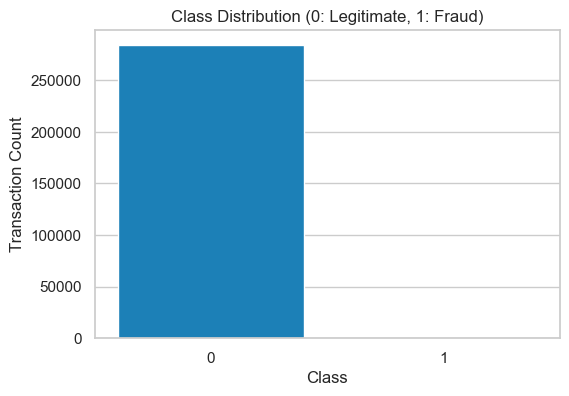

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette=['#0288D1', '#D84315'])
plt.title('Class Distribution (0: Legitimate, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Transaction Count')

# Calculate percentages
counts = df['Class'].value_counts()
n_legit = counts[0]
n_fraud = counts[1]
pct_legit = (n_legit / len(df)) * 100
pct_fraud = (n_fraud / len(df)) * 100

print(f"Legitimate Transactions (Class 0): {n_legit} ({pct_legit:.3f}%)")
print(f"Fraudulent Transactions (Class 1): {n_fraud} ({pct_fraud:.3f}%)")
plt.show()

### Analyzing Transaction Amounts
Let's compare the monetary values of fraudulent vs legitimate transactions.

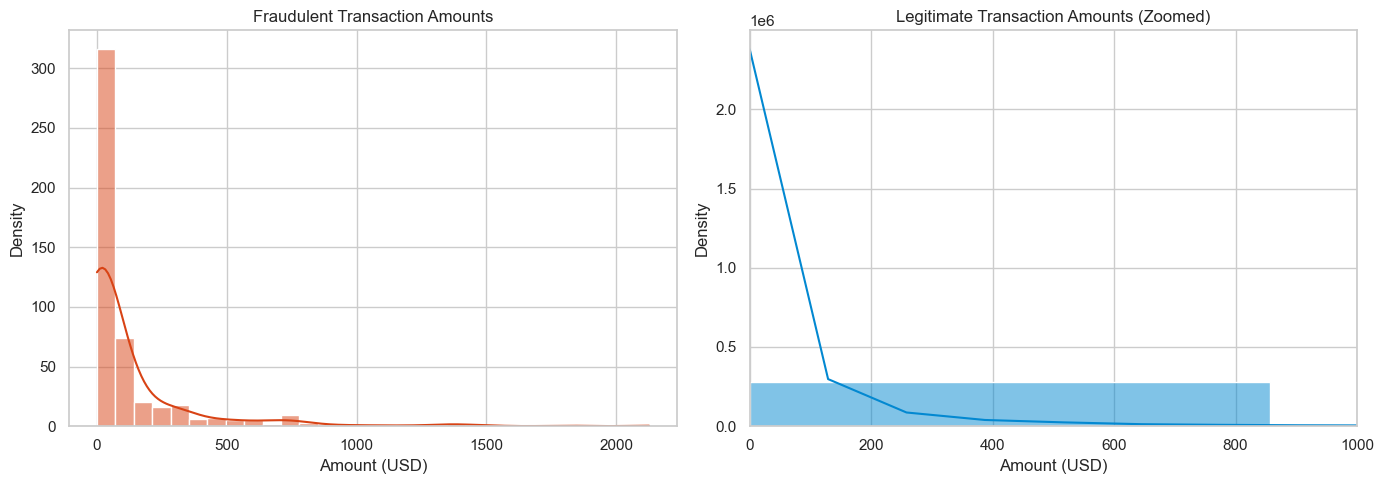

Average Fraud Amount: $122.21
Average Legit Amount: $88.29


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraudulent amounts
sns.histplot(df[df['Class'] == 1]['Amount'], bins=30, kde=True, ax=axes[0], color='#D84315')
axes[0].set_title('Fraudulent Transaction Amounts')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Density')

# Legitimate amounts
sns.histplot(df[df['Class'] == 0]['Amount'], bins=30, kde=True, ax=axes[1], color='#0288D1')
axes[1].set_title('Legitimate Transaction Amounts (Zoomed)')
axes[1].set_xlabel('Amount (USD)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 1000)  # Zoom in because most transactions are small

plt.tight_layout()
plt.show()

print(f"Average Fraud Amount: ${df[df['Class'] == 1]['Amount'].mean():.2f}")
print(f"Average Legit Amount: ${df[df['Class'] == 0]['Amount'].mean():.2f}")

### Correlation Analysis
Let's check the correlations across features. Since V1-V28 are PCA-engineered components, they are orthogonal (uncorrelated with each other), but they will correlate with the target class.

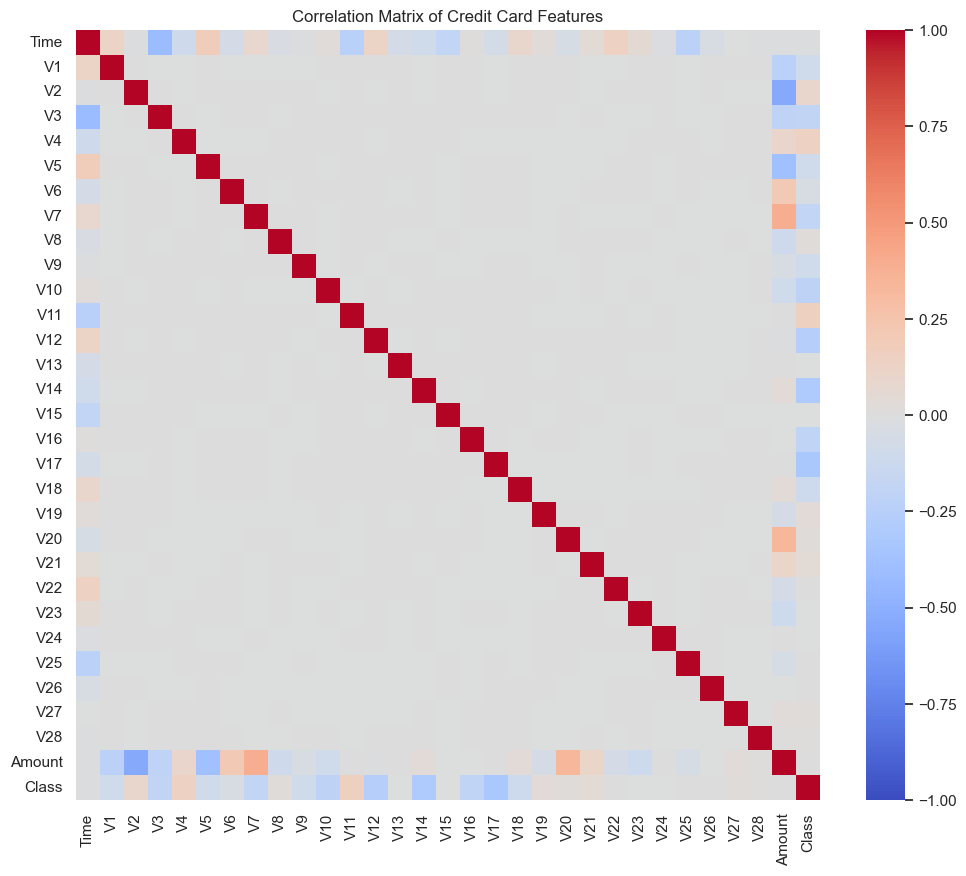

In [5]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', vmin=-1, vmax=1, xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix of Credit Card Features')
plt.show()

## Step 3: Splitting and Preprocessing
To prevent **Data Leakage**, we must split the data into training and test sets *before* performing scaling. 

The PCA features (V1-V28) are already scaled, but the `Time` and `Amount` columns contain large values. We will scale them using `StandardScaler` fitted on the training split only.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split into features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Stratified Train-Test split (critical for preserving the low minority target rates in splits)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize Scaler
scaler = StandardScaler()

# Fit only on training set and transform both
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (227845, 30)
X_test shape: (56962, 30)


## Step 4: Class Imbalance Handling
If we train a model directly on this dataset without adjustments, it can predict 0 (legitimate) for everything, giving 99.8% accuracy but missing 100% of fraud.

We will evaluate two methods:
1. **Algorithmic weights** (modifying class weights inside standard classifiers).
2. **SMOTE** (generating synthetic minority examples in the training set).

In [7]:
from imblearn.over_sampling import SMOTE

print("Original training target distribution:")
print(y_train.value_counts())

# Apply SMOTE strictly to the training split only!
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("\nResampled training target distribution (SMOTE):")
print(y_train_res.value_counts())

Original training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64



Resampled training target distribution (SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


## Step 5: Model Building & Comparison
Let's compare three different Logistic Regression models to see the impact of imbalance handling:
1. **Baseline Model** (no class adjustments).
2. **Weighted Model** (balanced weights adjusted in algorithm).
3. **SMOTE Model** (trained on resampled training set).

In [8]:
from sklearn.linear_model import LogisticRegression

# 1. Baseline Model
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

# 2. Class Weighted Model
lr_weighted = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_weighted.fit(X_train_scaled, y_train)

# 3. SMOTE Model
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_res, y_train_res)

print("Models trained successfully!")

Models trained successfully!


## Step 6: Evaluation & Metrics Trade-off
Let's write a utility function to evaluate each model. We prioritize **Recall** (catching all actual frauds) over **Precision** (avoiding false alarms) since missing a fraud case is extremely costly.

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9559



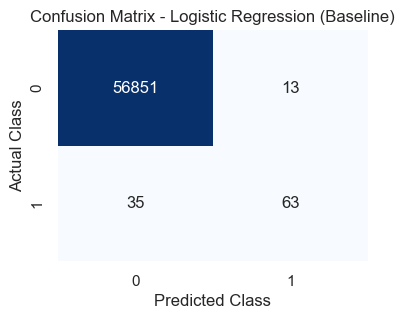

=== Logistic Regression (Class Weighted) ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC Score: 0.9722



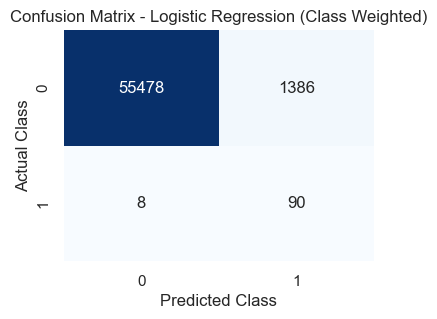

=== Logistic Regression (SMOTE) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9699



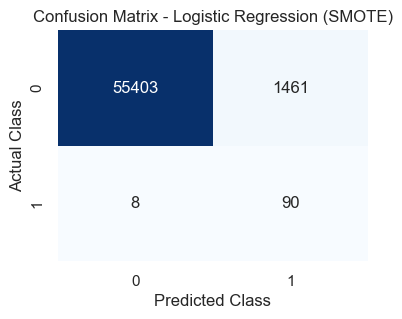

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}\n")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

evaluate_model(lr_baseline, X_test_scaled, y_test, "Logistic Regression (Baseline)")
evaluate_model(lr_weighted, X_test_scaled, y_test, "Logistic Regression (Class Weighted)")
evaluate_model(lr_smote, X_test_scaled, y_test, "Logistic Regression (SMOTE)")

### Advanced Ensembles: Random Forest & XGBoost
Let's train Random Forest and XGBoost classifiers with class weighting to see if complex algorithms boost F1-score and Recall.

=== Random Forest (Weighted) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9529



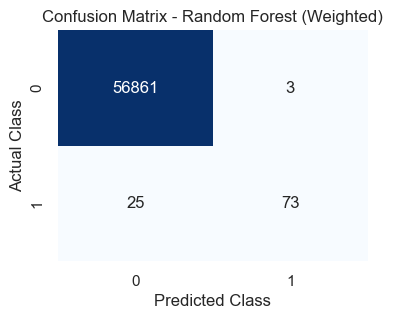

=== XGBoost (Weighted) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9726



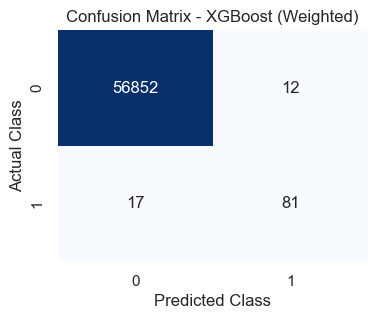

In [10]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest with balanced weights
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# XGBoost with scale_pos_weight
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

evaluate_model(rf, X_test_scaled, y_test, "Random Forest (Weighted)")
evaluate_model(xgb, X_test_scaled, y_test, "XGBoost (Weighted)")

## Step 7: Hyperparameter Tuning
We will tune the parameters of our XGBoost model using `RandomizedSearchCV`, scoring specifically on `'f1'` to balance precision and recall.

Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}
=== Tuned XGBoost ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9701



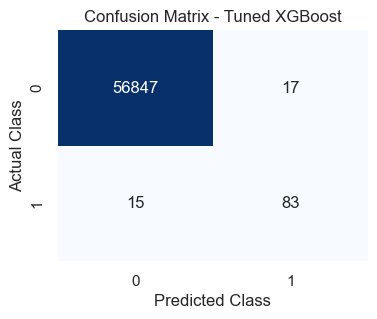

In [11]:
from sklearn.model_selection import RandomizedSearchCV

# Parameters distribution grid
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_scaled, y_train)
best_xgb = random_search.best_estimator_

print("Best Hyperparameters Found:", random_search.best_params_)
evaluate_model(best_xgb, X_test_scaled, y_test, "Tuned XGBoost")

## Step 8: Serialization & Save
Finally, we serialize and save both our trained scaler and the tuned XGBoost classifier to disk so they can be loaded and deployed in production environments.

In [12]:
import joblib

# Export files
joblib.dump(best_xgb, 'best_fraud_model.pkl')
joblib.dump(scaler, 'fraud_scaler.pkl')
print("Model and Scaler successfully saved to disk!")

Model and Scaler successfully saved to disk!
